<a href="https://colab.research.google.com/github/Kryptera-K/BF-B-BB-Squeeze-QQE-Trend-Filter-Strategy/blob/main/BF_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.8/527.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import vectorbt as vbt

# -------------------------
# Download Data
# -------------------------

symbol = "BF-B"
start_date = "2000-01-01"
end_date = "2026-01-01"
interval = "1d"

df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
df.to_csv("BF-B_clean.csv", index=False)
df

/tmp/ipython-input-2346506795.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,3.678606,3.710524,3.630728,3.638708,1075313
2000-01-04,3.610776,3.710521,3.574868,3.662644,806250
2000-01-05,3.638707,3.670625,3.590829,3.590829,744375
2000-01-06,3.662645,3.678605,3.614768,3.622747,1078125
2000-01-07,3.702545,3.706534,3.654667,3.654667,1163438
...,...,...,...,...,...
2025-12-24,26.889999,26.889999,26.370001,26.639999,2627500
2025-12-26,26.190001,26.930000,26.090000,26.780001,3442000
2025-12-29,26.110001,26.459999,26.000000,26.150000,4049700


In [ ]:
# -------------------------
# Necessary Parameters
# -------------------------

BB_PERIOD = 20
BB_SHIFT = 5
BB_STD = 2
QQE_FACTOR = 4.236
QQE_LEVEL = 50
QQE_PERIOD = 14
QQE_SMOOTH = 5

# -------------------------
# Indicator Functions
# -------------------------

def bb_squeeze(df, period=BB_PERIOD, std_multiplier=BB_STD, shift=BB_SHIFT):
    """
    Detect Bollinger Band Squeeze (bands narrowing)
    """
    df = calculate_bollinger_bands(df, period, std_multiplier)
    bandwidth = df['BB_Upper'] - df['BB_Lower']
    return bandwidth < bandwidth.shift(shift)


def calculate_bollinger_bands(df, period=BB_PERIOD, std_multiplier=BB_STD):
    """
    Calculate Bollinger Bands: Middle, Upper, and Lower.
    """
    df = df.copy()
    df['BB_MA'] = df['Close'].rolling(window=period).mean()
    df['BB_Upper'] = df['BB_MA'] + std_multiplier * df['Close'].rolling(window=period).std()
    df['BB_Lower'] = df['BB_MA'] - std_multiplier * df['Close'].rolling(window=period).std()
    return df


def qqe_cross_below_level(df, level=QQE_LEVEL):
    df = calculate_qqe(df)
    return (df['QQE_Value1'] < level) & (df['QQE_Value1'].shift(1) >= level)


def calculate_qqe(df, rsi_period=QQE_PERIOD, smooth=QQE_SMOOTH, factor=QQE_FACTOR):
    """
    Calculate QQE lines (Value1 & Value2) based on RSI smoothing and ATR-like smoothing.
    """
    df = df.copy()

    # --- RSI ---
    delta = df['Close'].diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.ewm(alpha=1/rsi_period, adjust=False).mean()
    roll_down = down.ewm(alpha=1/rsi_period, adjust=False).mean()
    rsi = 100 - (100 / (1 + roll_up / roll_down))

    # --- Smoothed RSI ---
    rsi_ma = rsi.rolling(window=smooth).mean().fillna(method='bfill')

    # --- RSI Delta & ATR-like smoothing ---
    rsi_delta = rsi_ma.diff().abs().fillna(0)
    atr_rsi = rsi_delta.ewm(alpha=1/smooth, adjust=False).mean()

    # --- QQE Calculation ---
    value1 = rsi_ma.copy()
    value2 = pd.Series(index=df.index, dtype=float)
    value2.iloc[0] = value1.iloc[0]

    for i in range(1, len(df)):
        prev_trail = value2.iloc[i-1]
        prev_value1 = value1.iloc[i-1]
        atr = atr_rsi.iloc[i]
        direction = 1 if prev_value1 > prev_trail else -1
        value2.iloc[i] = prev_trail + direction * factor * atr

    df['QQE_Value1'] = value1
    df['QQE_Value2'] = value2

    return df



# -------------------------
# Entry conditions
# -------------------------

df["BB_Squeeze"] = bb_squeeze(df)

# -------------------------
# Exit conditions
# -------------------------

df["QQE_Value1_CrossBelow_Level"] = qqe_cross_below_level(df)

# -------------------------
# Signals
# -------------------------

entry_conditions = [
    'BB_Squeeze',
]
exit_conditions = [
    'QQE_Value1_CrossBelow_Level',
]

df['entry_signal'] = df[entry_conditions].all(axis=1)
df['exit_signal']  = df[exit_conditions].all(axis=1)

# -------------------------
# Backtest
# -------------------------


shift_entries = df['entry_signal'].shift(1).astype(bool).fillna(False).to_numpy()
shift_exits = df['exit_signal'].shift(1).astype(bool).fillna(False).to_numpy()

pf = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shift_entries,
    exits=shift_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='1d'
)


# -------------------------
# Portfolio Stats / Plot
# -------------------------

print(pf.stats())
pf.plot().show()

/tmp/ipython-input-3168282350.py:57: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  rsi_ma = rsi.rolling(window=smooth).mean().fillna(method='bfill')


Start                                 2000-01-03 00:00:00
End                                   2025-12-31 00:00:00
Period                                 6539 days 00:00:00
Start Value                                      100000.0
End Value                                   875705.151756
Total Return [%]                               775.705152
Benchmark Return [%]                            617.01281
Max Gross Exposure [%]                              100.0
Total Fees Paid                             109034.018972
Max Drawdown [%]                                57.807083
Max Drawdown Duration                  1333 days 00:00:00
Total Trades                                           63
Total Closed Trades                                    62
Total Open Trades                                       1
Open Trade PnL                              -55255.999192
Win Rate [%]                                     54.83871
Best Trade [%]                                  61.092126
Worst Trade [%

In [ ]:
# Buy and Hold Performance Metrics
df_holding = df['Open']
pf_holding = vbt.Portfolio.from_holding(df_holding, init_cash=100_000 , freq='D')
print(pf_holding.stats())

Start                         2000-01-03 00:00:00
End                           2025-12-31 00:00:00
Period                         6539 days 00:00:00
Start Value                              100000.0
End Value                           717012.810115
Total Return [%]                        617.01281
Benchmark Return [%]                    617.01281
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                         65.88252
Max Drawdown Duration          1149 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                      617012.810115
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN


/tmp/ipython-input-3168282350.py:57: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipython-input-3168282350.py:57: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



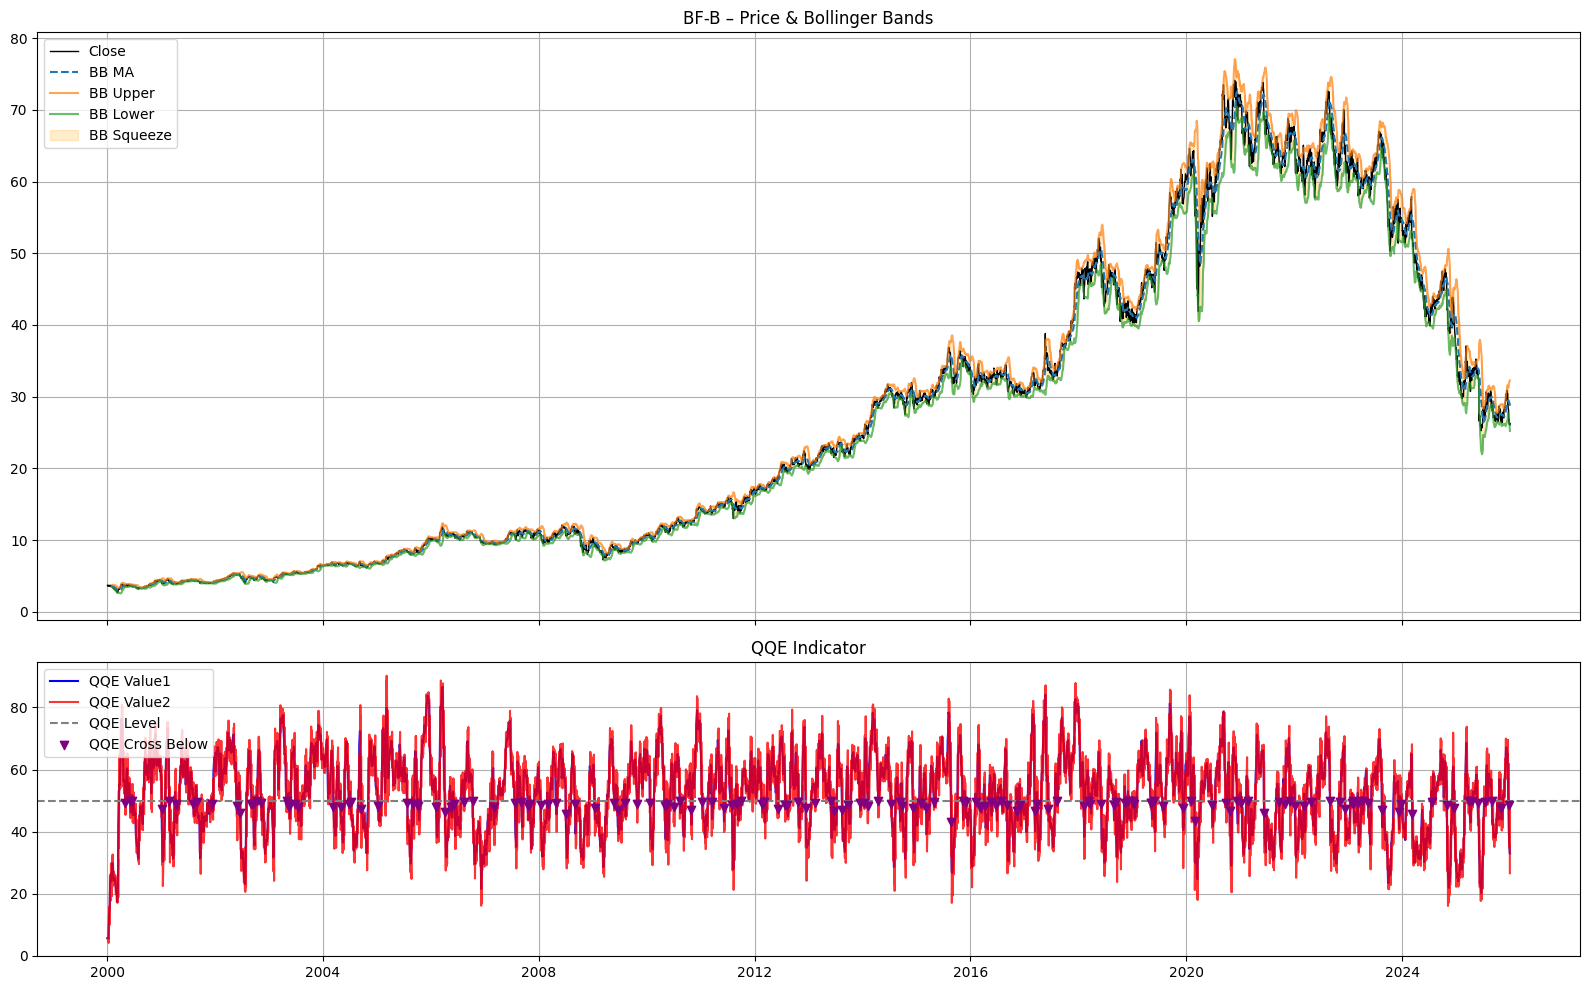

In [ ]:
import matplotlib.pyplot as plt

# -------------------------
# Calculate Indicators
# -------------------------

df = calculate_bollinger_bands(df)
df["BB_Squeeze"] = bb_squeeze(df)
df = calculate_qqe(df)
df["QQE_Cross_Below"] = qqe_cross_below_level(df)

# -------------------------
# Plot
# -------------------------

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 10), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

# ===== Price + Bollinger Bands =====
ax1.plot(df.index, df["Close"], label="Close", color="black", linewidth=1)
ax1.plot(df.index, df["BB_MA"], label="BB MA", linestyle="--")
ax1.plot(df.index, df["BB_Upper"], label="BB Upper", alpha=0.7)
ax1.plot(df.index, df["BB_Lower"], label="BB Lower", alpha=0.7)

# Highlight BB Squeeze
ax1.fill_between(
    df.index,
    df["BB_Lower"],
    df["BB_Upper"],
    where=df["BB_Squeeze"],
    color="orange",
    alpha=0.2,
    label="BB Squeeze"
)

ax1.set_title(f"{symbol} – Price & Bollinger Bands")
ax1.legend(loc="upper left")
ax1.grid(True)

# ===== QQE Panel =====
ax2.plot(df.index, df["QQE_Value1"], label="QQE Value1", color="blue")
ax2.plot(df.index, df["QQE_Value2"], label="QQE Value2", color="red", alpha=0.8)
ax2.axhline(QQE_LEVEL, color="gray", linestyle="--", label="QQE Level")

# Mark QQE Cross Below Level
ax2.scatter(
    df.index[df["QQE_Cross_Below"]],
    df.loc[df["QQE_Cross_Below"], "QQE_Value1"],
    color="purple",
    marker="v",
    label="QQE Cross Below",
    zorder=3
)

ax2.set_title("QQE Indicator")
ax2.legend(loc="upper left")
ax2.grid(True)

plt.tight_layout()
plt.show()
